# 專題(HW4)：透過 LLM 與 Jieba 生成關聯圖



# step 1 先安裝必要的套件與系統中文字型

In [3]:
# 1. 安裝 Llama3 輕量化所需套件與畫圖套件
!pip install transformers torch accelerate bitsandbytes
!pip install jieba networkx matplotlib pandas

# 2. 安裝系統中文字型 (避免關聯圖出現方塊亂碼)
!apt-get -qq install -y fonts-noto-cjk


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 13.6 MB/s eta 0:00:00
Selecting previously unselected package fonts-noto-cjk.
(Reading database ... 122354 files and directories currently installed.)
Preparing to unpack .../fonts-noto-cjk_1%3a20220127+repack1-1_all.deb ...
Unpacking fonts-noto-cjk (1:20220127+repack1-1) ...
Setting up fonts-noto-cjk (1:20220127+repack1-1) ...
Processing triggers for fontconfig (2.13.1-4.2ubuntu5) ...


# step2 載入資料與 Llama 3 模型

In [4]:
import pandas as pd
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig
import torch

print("【1】正在讀取 PTT 資料...")
# 讀取你上傳的 CSV 檔案
df = pd.read_csv('ptt_gossiping_data_hw4.csv')
print(f"資料讀取成功！共有 {len(df)} 篇文章。")

print("【2】正在下載並載入 Llama-3-8B-Instruct (4-bit 輕量版)...")
model_name = "unsloth/llama-3-8b-Instruct-bnb-4bit"

# 設定 4-bit 量化，節省 Colab 記憶體
quantization_config = BitsAndBytesConfig(load_in_4bit=True)
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForCausalLM.from_pretrained(
    model_name,
    quantization_config=quantization_config,
    device_map="auto"
)
print("模型載入完成！")


【1】正在讀取 PTT 資料...
資料讀取成功！共有 193 篇文章。
【2】正在下載並載入 Llama-3-8B-Instruct (4-bit 輕量版)...


config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/345 [00:00<?, ?B/s]

/usr/local/lib/python3.12/dist-packages/transformers/quantizers/auto.py:246: UserWarning: You passed `quantization_config` or equivalent parameters to `from_pretrained` but the model you're loading already has a `quantization_config` attribute. The `quantization_config` from the model will be used.
  warnings.warn(warning_msg)


model.safetensors:   0%|          | 0.00/5.70G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/220 [00:00<?, ?B/s]

模型載入完成！


### 內文名詞頻率統計

這裡將計算所有文章內文經過 Jieba 精準斷詞後提取的名詞的頻率。這個統計結果可以用來了解文章集合中哪些名詞最常被提及。

In [9]:
from collections import Counter

# 統計所有文章內文名詞的頻率
noun_frequencies_from_articles = Counter(all_nouns_for_frequency_statistics)

print("【文章內文名詞頻率統計】")
# 按照頻率由高到低排序並顯示前 20 個名詞
for noun, freq in noun_frequencies_from_articles.most_common(20):
    print(f"  {noun}: {freq} 次")

print("\n頻率統計完成！")

NameError: name 'all_nouns_for_frequency_statistics' is not defined

# step3: 內文分析 (Llama 3) + 文字處理 (Jieba)

這一步將結合 Llama 3 和 Jieba 進行文本分析。Llama 3 將從文章中提取關鍵詞，而 Jieba 則負責精準斷詞並篩選出名詞。這些名詞將分別用於後續的關聯圖建構和頻率統計。

In [24]:
import jieba
import jieba.analyse
import itertools
import jieba.posseg as posseg # Import posseg for part-of-speech tagging

# 檢查 Jieba 是否已載入詞庫，若無則使用預設詞庫
# 如果需要載入特定詞庫 (如 'dict.txt.big')，請確保該文件存在於執行環境中
# if not jieba.dt.check_initialized():
#     jieba.set_dictionary('dict.txt.big') # 如果需要特定詞庫，請取消註解此行

# 定義 Llama 3 文本分析函數
def analyze_with_llama(text):
    messages = [
        # 修改系統提示，讓 LLM 直接列出關鍵名詞/實體，而不是總結
        {"role": "system", "content": "你是一個精準的文本分析專家。請閱讀 PTT 鄉民的文章，並列出文章中所有關鍵的名詞、人物、地點或重要概念，以逗號分隔。不要輸出多餘的解釋或句子。請全數翻譯成繁體中文"},
        {"role": "user", "content": f"文章內容：\n{text}"}
    ]

    encoded_inputs = tokenizer.apply_chat_template(
        messages, add_generation_prompt=True, return_tensors="pt"
    )
    input_ids_tensor = encoded_inputs['input_ids'].to(model.device)

    outputs = model.generate(
        input_ids_tensor,
        max_new_tokens=50, # 假設 LLM 列出的關鍵詞不會太長
        temperature=0.3,
        pad_token_id=tokenizer.eos_token_id
    )
    response = tokenizer.decode(outputs[0][input_ids_tensor.shape[-1]:], skip_special_tokens=True)
    return response.strip()

print("""開始進行文本分析管線：
1. Llama 3 提取關鍵詞 -> Jieba 精準斷詞名詞萃取 (用於關聯圖)
2. 文章內文 -> Jieba 精準斷詞名詞萃取 (用於頻率統計)""")

# 儲存從 Llama 3 提取並經 Jieba 處理的關鍵詞列表 (每個子列表代表一篇文章的關鍵詞)，用於後續關聯圖
all_keywords_for_relationship_graph = []
# 儲存從每篇文章內文精準斷詞後提取的所有名詞，用於頻率統計
all_nouns_for_frequency_statistics = []

# 為了節省時間，我們先取前 50 篇文章做示範
articles = df['content'].head(50).tolist()

for i, text in enumerate(articles):
    # 確保 text 是字串類型，避免因內容為 None 或數字型態引起錯誤
    article_text_str = str(text)

    # 1. Llama 3 提取關鍵詞 (使用文章前 500 字，以控制模型輸入長度與成本)
    short_text_for_llama = article_text_str[:500]
    llama_extracted_keywords_str = analyze_with_llama(short_text_for_llama) # LLM直接輸出關鍵詞字符串

    # 2. 針對 Llama 3 提取的關鍵詞進行 Jieba 精準斷詞並萃取名詞 (用於關聯圖)
    # 我們將 LLM 輸出的字串視為要斷詞的文本，應用 Jieba 進行詞性標註和篩選
    pos_tagged_llama_output = posseg.cut(llama_extracted_keywords_str) # Changed to posseg.cut
    noun_tags = ['n', 'nr', 'ns', 'nt', 'nz', 'vn'] # 定義名詞詞性標籤
    # 篩選出名詞且長度大於1，避免單字雜訊，並將名詞轉為小寫統一處理
    current_article_keywords_for_graph = [word.word.lower() for word in pos_tagged_llama_output if word.flag in noun_tags and len(word.word) > 1] # Access word.word and word.flag
    if current_article_keywords_for_graph:
        all_keywords_for_relationship_graph.append(current_article_keywords_for_graph)

    # 3. 針對完整的文章內文進行精準斷詞並萃取所有名詞 (用於頻率統計)
    pos_tagged_words_from_article = posseg.cut(article_text_str) # Changed to posseg.cut
    current_article_nouns_for_freq = [word.word.lower() for word in pos_tagged_words_from_article if word.flag in noun_tags and len(word.word) > 1] # Access word.word and word.flag
    all_nouns_for_frequency_statistics.extend(current_article_nouns_for_freq)

    print(f"文章 {i+1}:")
    print(f"  [Llama3 提取關鍵詞 (原始)] {llama_extracted_keywords_str}")
    print(f"  [Jieba 關聯圖名詞] {current_article_keywords_for_graph}")
    print(f"  [Jieba 內文精準名詞 (部分範例)] {current_article_nouns_for_freq[:5]}...") # 只顯示前5個名詞作為範例
    print("-" * 20)

print("分析處理完成！")

開始進行文本分析管線：
1. Llama 3 提取關鍵詞 -> Jieba 精準斷詞名詞萃取 (用於關聯圖)
2. 文章內文 -> Jieba 精準斷詞名詞萃取 (用於頻率統計)
文章 1:
  [Llama3 提取關鍵詞 (原始)] 名詞、人物、地點或重要概念：股市, 麗寶, 七折預售, 房價, FOMO
  [Jieba 關聯圖名詞] ['名詞', '人物', '地點', '概念', '股市', '麗寶', '預售', '房價']
  [Jieba 內文精準名詞 (部分範例)] ['股市', '麗寶', '預售', '房價', '大家']...
--------------------
文章 2:
  [Llama3 提取關鍵詞 (原始)] 名詞、人物、地點或重要概念：木村牛丼、廣告、蕎麥麵、YouTube、桌子、手肘、日本人、規矩、PTT
  [Jieba 關聯圖名詞] ['名詞', '人物', '地點', '概念', '木村', '廣告', '蕎麥', '桌子', '手肘', '日本', '規矩']
  [Jieba 內文精準名詞 (部分範例)] ['木村', '吃蕎', '手肘', '桌子', '手肘']...
--------------------
文章 3:
  [Llama3 提取關鍵詞 (原始)] 名詞、人物、地點或重要概念：

隔壁科, 女, 單身, 休假, 公文, 疾病, 痊癒, 主管, 病假, 診所, 大
  [Jieba 關聯圖名詞] ['名詞', '人物', '地點', '概念', '單身', '公文', '疾病', '主管', '病假']
  [Jieba 內文精準名詞 (部分範例)] ['問題', '人物', '單身', '公文', '身心']...
--------------------
文章 4:
  [Llama3 提取關鍵詞 (原始)] Here are the key terms, people, locations, and concepts from the article, separated by commas:

民進黨, 賴清德, 中國, 台灣, 國防, 美國, 國際社會, 立法院, 軍
  [Jieba 關聯圖名詞] ['民進黨', '賴清德', '中國', '台灣', '國防', '美國', '國際社會'

### 關聯圖關鍵詞整理

`all_keywords_for_relationship_graph` 是一個列表，其中每個元素又是一個列表，代表單篇文章經 Llama 3 提取並由 Jieba 處理後的重要名詞。這個結構非常適合用於建立關聯圖 (Co-occurrence Graph)。

我們可以將這個結構轉換成一個鄰接列表 (Adjacency List) 字典，以方便 NetworkX 等圖形庫進行關聯圖的建構。字典的鍵為名詞，值為與該名詞共同出現在同篇文章中的其他名詞及其共同出現的次數。


In [25]:
from collections import defaultdict

# 初始化一個字典，用於儲存關聯圖的鄰接列表
# 鍵是名詞，值是另一個字典，表示與該名詞相關的名詞及其共同出現的次數
relationship_graph_data = defaultdict(lambda: defaultdict(int))

# 遍歷每篇文章的關鍵詞列表
for keywords_in_article in all_keywords_for_relationship_graph:
    # 確保列表中的每個詞都與其他詞建立關聯
    for i, keyword1 in enumerate(keywords_in_article):
        for j, keyword2 in enumerate(keywords_in_article):
            if i != j: # 避免自己與自己關聯
                # 將所有關鍵詞轉為小寫，確保一致性
                k1 = keyword1.lower()
                k2 = keyword2.lower()
                relationship_graph_data[k1][k2] += 1

print("【關聯圖字典範例 (部分顯示)】")
# 顯示前 5 個關鍵詞及其關聯名詞與次數
count = 0
for main_keyword, connected_keywords in relationship_graph_data.items():
    if count < 5: # 只顯示前5個主要關鍵詞
        print(f"  {main_keyword}:")
        # 對關聯名詞按次數排序，並顯示前 3 個
        sorted_connected = sorted(connected_keywords.items(), key=lambda item: item[1], reverse=True)
        for connected_keyword, freq in sorted_connected[:3]:
            print(f"    - {connected_keyword}: {freq} 次")
        count += 1
    else:
        break

print("\n關聯圖字典已建立，可供 NetworkX 等圖形庫使用。")

【關聯圖字典範例 (部分顯示)】
  名詞:
    - 人物: 25 次
    - 地點: 24 次
    - 概念: 24 次
  人物:
    - 名詞: 25 次
    - 地點: 25 次
    - 概念: 25 次
  地點:
    - 人物: 25 次
    - 名詞: 24 次
    - 概念: 24 次
  概念:
    - 人物: 25 次
    - 名詞: 24 次
    - 地點: 24 次
  股市:
    - 名詞: 1 次
    - 人物: 1 次
    - 地點: 1 次

關聯圖字典已建立，可供 NetworkX 等圖形庫使用。


### 視覺化關聯圖

使用 `NetworkX` 和 `Matplotlib` 將 `relationship_graph_data` 轉換為視覺化的關聯圖。每個節點代表一個名詞，節點之間有共同出現關係的名詞將被一條邊連接。邊的粗細和顏色可以根據它們的共同出現頻率來調整，以便更容易識別重要的關聯。

Using font file: /usr/share/fonts/opentype/noto/NotoSansCJK-Regular.ttc
Registered font family name: Noto Sans CJK JP
【正在建立關聯圖...】


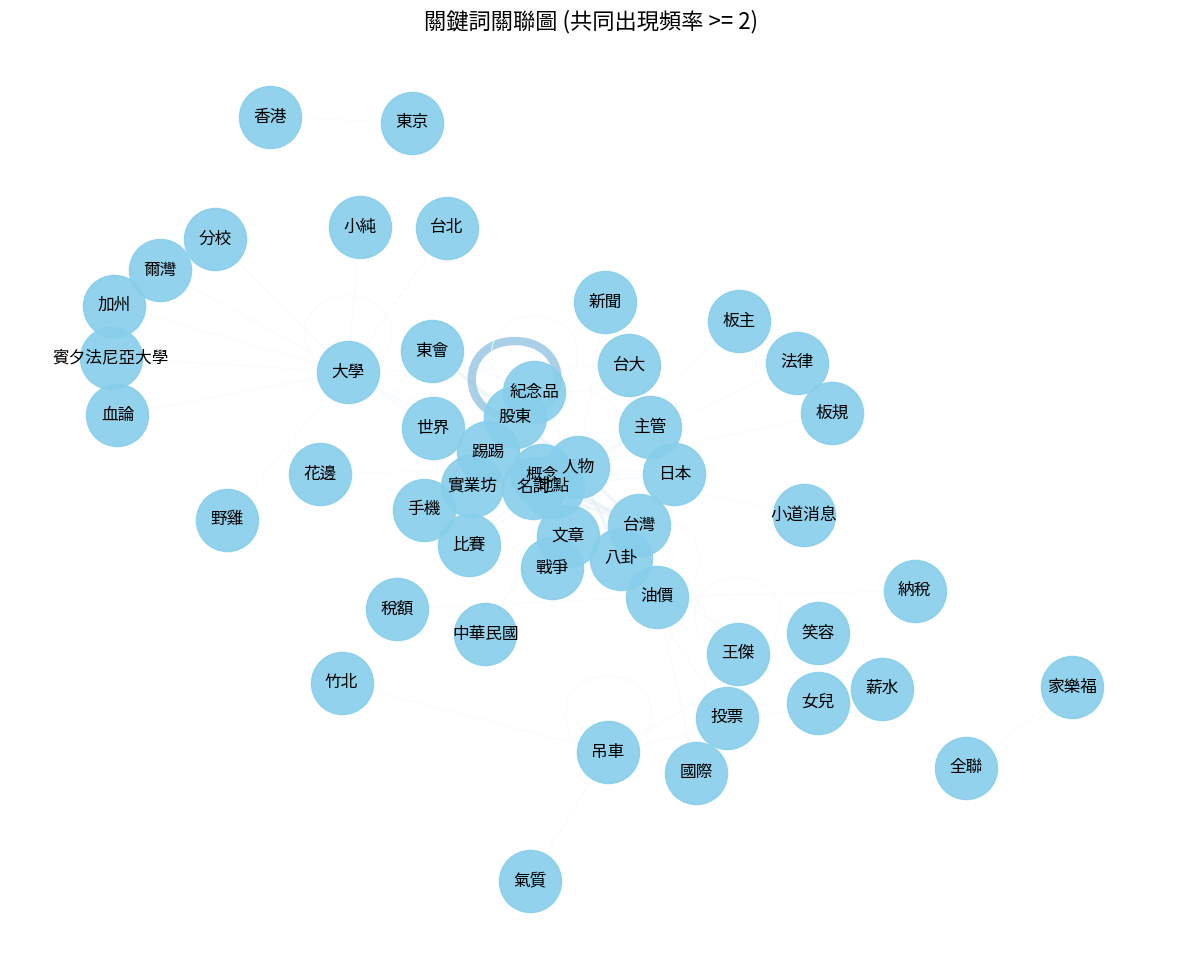

關聯圖繪製完成！


In [28]:
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import os # Add import for os

# Rebuild font cache to ensure newly installed fonts are recognized
# This should be done after font installation to ensure matplotlib picks them up.
# fm.fontManager.rebuild() # Removed: This line caused an AttributeError

# Define a list of common Noto CJK font paths that should be available after apt-get install
# We'll try to find an existing one.
font_paths_to_try = [
    '/usr/share/fonts/opentype/noto/NotoSansCJKtc-Regular.otf', # Traditional Chinese (often available)
    '/usr/share/fonts/opentype/noto/NotoSansCJKjp-Regular.otf', # Japanese
    '/usr/share/fonts/opentype/noto/NotoSansCJKkr-Regular.otf', # Korean
    '/usr/share/fonts/opentype/noto/NotoSansCJKsc-Regular.otf', # Simplified Chinese
    '/usr/share/fonts/opentype/noto/NotoSansCJK-Regular.ttc',   # Generic CJK TrueType
    '/usr/share/fonts/truetype/noto/NotoSansCJK-Regular.ttc',   # Another common path for .ttc
]

selected_font_path = None
for p in font_paths_to_try:
    if os.path.exists(p):
        selected_font_path = p
        break

if selected_font_path:
    print(f"Using font file: {selected_font_path}")
    # Explicitly add the font file to font manager
    fm.fontManager.addfont(selected_font_path)
    # Get the font name from the file (e.g., 'Noto Sans CJK')
    font_name = fm.FontProperties(fname=selected_font_path).get_name()
    print(f"Registered font family name: {font_name}")

    # Set the font to be used by Matplotlib globally for sans-serif fonts
    # Add the found font name to the beginning of the sans-serif list to prioritize it
    plt.rcParams['font.sans-serif'] = [font_name] + plt.rcParams['font.sans-serif']
    plt.rcParams['font.family'] = 'sans-serif'
    # Create font_prop for consistent use in labels and title properties
    font_prop = fm.FontProperties(fname=selected_font_path, size=10)
else:
    print("Warning: No specific Noto CJK font file found. Using generic sans-serif font.")
    font_name = 'sans-serif' # Fallback name
    plt.rcParams['font.family'] = font_name
    font_prop = fm.FontProperties(family=font_name, size=10) # Create font_prop for consistency

plt.rcParams['axes.unicode_minus'] = False # 解決負號亂碼問題

print("【正在建立關聯圖...】")
G = nx.Graph()

# 添加節點和邊
for k1, connected_keywords in relationship_graph_data.items():
    G.add_node(k1) # 確保所有關鍵詞都是節點
    for k2, weight in connected_keywords.items():
        if weight > 0: # 只添加有實際關聯的邊
            G.add_edge(k1, k2, weight=weight)

# 過濾弱連接，只保留頻率高於特定閾值的邊，避免圖形過於混亂
# 您可以根據實際數據調整這個閾值
threshold = 2 # 例如，共同出現次數至少為2次
# Fix: Pass the weight as a dictionary {'weight': d['weight']} instead of just d['weight']
filtered_edges = [(u, v, {'weight': d['weight']}) for u, v, d in G.edges(data=True) if d['weight'] >= threshold]

# 創建一個新的圖，只包含過濾後的邊及其相關節點
G_filtered = nx.Graph()
G_filtered.add_edges_from(filtered_edges)

# 移除孤立的節點 (即沒有達到閾值的連接的節點)
# 這裡的邏輯是，如果一個節點沒有任何邊在 G_filtered 中，它就會被自動忽略
# 如果需要明確移除，可以這樣做：
# isolated_nodes = list(nx.isolates(G_filtered))
# G_filtered.remove_nodes_from(isolated_nodes)

if not G_filtered.nodes():
    print("沒有足夠的節點達到閾值來繪製關聯圖，請嘗試降低閾值。")
else:
    plt.figure(figsize=(15, 12))

    # 選擇佈局算法，例如 Spring layout
    pos = nx.spring_layout(G_filtered, k=0.5, iterations=50, seed=42) # k為節點間的理想距離，iterations為迭代次數，seed為隨機數種子

    # 獲取邊的權重列表，用於設置邊的粗細和顏色
    # Note: G_filtered.edges(data=True) will now return (u, v, {'weight': value}), so extract value correctly
    edge_weights = [d['weight'] for (u, v, d) in G_filtered.edges(data=True)]

    # 繪製節點
    nx.draw_networkx_nodes(G_filtered, pos, node_size=2000, node_color='skyblue', alpha=0.9)

    # 繪製邊，根據權重調整粗細和顏色
    nx.draw_networkx_edges(G_filtered, pos, width=[w*0.5 for w in edge_weights],
                           alpha=0.7, edge_color=edge_weights, edge_cmap=plt.cm.Blues)

    # 繪製節點標籤
    nx.draw_networkx_labels(G_filtered, pos, font_size=12, font_color='black', font_family=font_name) # Changed to font_name

    plt.title('關鍵詞關聯圖 (共同出現頻率 >= {})'.format(threshold), fontproperties=font_prop, size=16)
    plt.axis('off') # 不顯示坐標軸
    plt.show()

print("關聯圖繪製完成！")